### Example: Plotting a function of two variables

Consider $f(x,y) = x^2 + 2y^2 + 4x + y + 6$. Below, we graph this function in 3D using the `mpl_toolkits.mplot3d` module provided by `matplotlib`.

In [2]:
import numpy as np  # arrays
import matplotlib.pyplot as plt  # 2d plotting
from mpl_toolkits.mplot3d import axes3d  # 3d plotting

f = lambda x, y: x**2 + 2*y**2 + 4*x + y + 6
f(1,-1)

12

In [3]:
X = np.linspace(-10,10,300)
Y = np.linspace(-10,10,300)
Xmesh, Ymesh = np.meshgrid(X,Y)  # creates 300x300 grid of points defined by X and Y above
Z = f(Xmesh, Ymesh)  # evaluate f at each of the 300x300 points

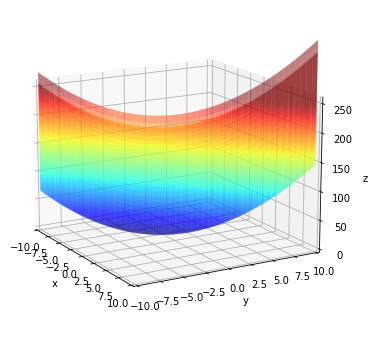

In [4]:
fig = plt.figure(figsize=(10, 6))
# feel free to play with the arguments below to get a feel for 3D plotting:
#     elev is angle above xy-plane, azim is angle around z-axis
#     Ex: elev=0, azim=0 shows yz-plane with positive x-axis out of screen
ax = plt.axes(projection='3d', elev=15, azim=-30)
ax.plot_surface(X, Y, Z, cmap='jet', alpha=0.5, vmax=250)
ax.set(xlabel='x', ylabel='y', zlabel='z', xlim=[-10,10], ylim=[-10,10], zlim=[0, 256])
plt.show()

Output of meshgrid, Xmesh and Ymesh, represent the pairwise x-y coordinates of the surface.

X and Y represent the X and Y axes.

Grid is 300x300

Xmesh is 300x300

X is 300x1

In [6]:
X.shape

(300,)

Each contour represents the values f(x,y) = c

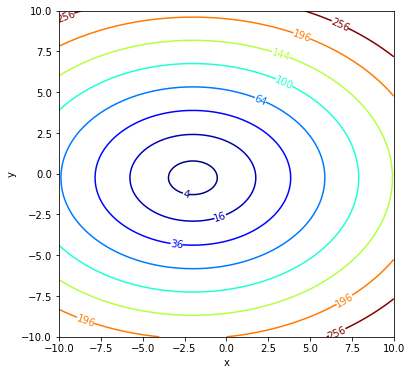

In [8]:
plt.figure(figsize=(6, 6)) 
CS = plt.contour(Xmesh, Ymesh, Z, np.arange(2,18,2)**2, cmap='jet', vmax=250) # fourth
# CS = plt.contour(X, Y, Z, np.arange(2,18,2)**2, cmap='jet', vmax=250) # fourth
# label the contours along the lines; without inline_spacing, too much white space 
plt.clabel(CS,inline_spacing=0,fmt='%d') 
plt.axis([-10,10,-10,10]) 
plt.xlabel('x') 
plt.ylabel('y') 
plt.show() 

`plt.contour(X, Y, Z, levels, color options)`:

X, Y can either be Xmesh,Ymesh or X,Y - it'll work fine either way.

levels is an array of increasing numbers (must be in increasing order). 

# Numpy ranges

`np.arange(start, stop, step)`: returns an array with evenly spaced elements in this interval (not including the stop point)

Increasing sequence of numbers from 2 to 18 counting by 2

In [5]:
np.arange(2, 18, 2)

array([ 2,  4,  6,  8, 10, 12, 14, 16])

Decreasing sequence of numbers from -2 to -18 counting by -2

In [14]:
-np.arange(2,18,2)**2
# To reverse the array, 
(-np.arange(2,18,2)**2)[::-1]

array([-256, -196, -144, -100,  -64,  -36,  -16,   -4])

Constructing contour plots for $f(x,y) = x^2 + 3xy - 6y^2 + 5x -9y + 4$ and $f(x,y) = 2 - x^2 - xy - y^2$

$f(x,y) = 2 - x^2 - xy - y^2$ has a local maximum at $(-1,-1)$

This function is negative so these contours are empty. It shoule be an increasing sequence of negative numbers if you want negative contours. 

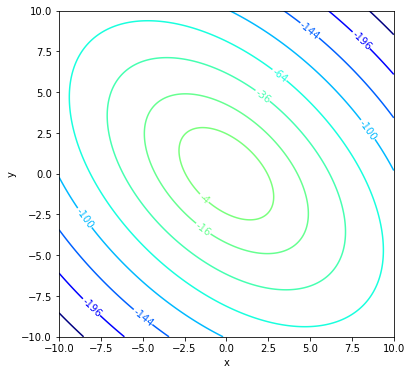

In [16]:
f = lambda x, y: 2 - x**2 - x*y - y**2
Z = f(Xmesh, Ymesh)  # evaluate f at each of the 300x300 points
plt.figure(figsize=(6, 6)) 

# For the levels, they must be increasing.
CS = plt.contour(Xmesh, Ymesh, Z, (-np.arange(2,18,2)**2)[::-1], cmap='jet', vmax=250) # fourth
# CS = plt.contour(X, Y, Z, np.arange(2,18,2)**2, cmap='jet', vmax=250) # fourth
# label the contours along the lines; without inline_spacing, too much white space 
plt.clabel(CS,inline_spacing=0,fmt='%d') 
plt.axis([-10,10,-10,10]) 
plt.xlabel('x') 
plt.ylabel('y') 
plt.show() 

f(x) = x^2+3xy-6y^2+5x-9y+4 does not have a local minimum at (-1,-1)

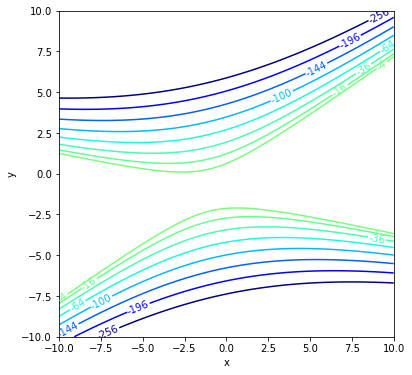

In [19]:
f = lambda x, y: x**2+3*x*y-6 * y**2+5*x-9*y+4
Z = f(Xmesh, Ymesh)  # evaluate f at each of the 300x300 points
plt.figure(figsize=(6, 6)) 

# For the levels, they must be increasing.
CS = plt.contour(Xmesh, Ymesh, Z, (-np.arange(2,18,2)**2)[::-1], cmap='jet', vmax=250) # fourth
# CS = plt.contour(X, Y, Z, np.arange(2,18,2)**2, cmap='jet', vmax=250) # fourth
# label the contours along the lines; without inline_spacing, too much white space 
plt.clabel(CS,inline_spacing=0,fmt='%d') 
plt.axis([-10,10,-10,10]) 
plt.xlabel('x') 
plt.ylabel('y') 
plt.show() 

In [ ]:
ef fixed_step_steepest_decent_method(objFunc, gradObjFunc, alpha,  x0, tol, 
maxIter):
    path      = [x0]
    k         = 0
    xk        = x0
    pk        = -gradObjFunc(x0)
    while norm(pk) > tol and k <= maxIter:
        xk  = xk + alpha * pk 
        pk  = -gradObjFunc(xk)
        k   = k + 1
        path.append(xk)
        
    path = np.array(path) # convert to array
        
    if norm(pk) <= tol:
        print("Found the minimizer at {x} with {iter} iterations successfully, 
gradient's norm is {nrm}.".format(x=xk,iter=k,nrm=norm(pk)))
    else:
        print("Unable to locate minimizer within maximum iterations, last 
position is at {x}, gradient's norm is {nrm}".format(x=xk,nrm=norm(pk)))
        
    return xk, k, path